In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_final = pd.read_csv("C:/Users/admin/Downloads/datasets/final_prediction_dataset.csv")

In [2]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1000 non-null   str    
 1   actual_liquidity       1000 non-null   int64  
 2   loan_inflows           1000 non-null   int64  
 3   borrowing_outflows     1000 non-null   float64
 4   repo_rate              1000 non-null   float64
 5   cp_rate                1000 non-null   float64
 6   liquidity_index        1000 non-null   float64
 7   alm_gap                1000 non-null   int64  
 8   funding_risk_exposure  1000 non-null   int64  
 9   variance               1000 non-null   int64  
 10  predicted_liquidity    1000 non-null   float64
 11  scenario               1000 non-null   str    
 12  breach_flag            1000 non-null   int64  
 13  liquidity_risk_score   1000 non-null   float64
dtypes: float64(6), int64(6), str(2)
memory usage: 125.1 KB


In [3]:
df_final['date'] = pd.to_datetime(df_final['date'])

In [4]:
df_final['date']

0     2024-01-01
1     2024-01-02
2     2024-01-03
3     2024-01-04
4     2024-01-05
         ...    
995   2025-05-10
996   2025-05-11
997   2025-05-12
998   2025-05-13
999   2025-05-14
Name: date, Length: 1000, dtype: datetime64[us]

In [5]:
df_final['predicted_liquidity_30d'] = (
    df_final['predicted_liquidity']
    .rolling(window=30, min_periods=1)
    .mean()
)

df_final['predicted_liquidity_60d'] = (
    df_final['predicted_liquidity']
    .rolling(window=60, min_periods=1)
    .mean()
)

df_final['predicted_liquidity_90d'] = (
    df_final['predicted_liquidity']
    .rolling(window=90, min_periods=1)
    .mean()
)


In [6]:
df_final['predicted_liquidity_30d']

0     -4.115570e+05
1     -1.255290e+06
2     -1.015240e+06
3     -5.830555e+05
4     -5.521182e+05
           ...     
995   -3.953848e+05
996   -4.067790e+05
997   -4.129225e+05
998   -4.064296e+05
999   -4.633866e+05
Name: predicted_liquidity_30d, Length: 1000, dtype: float64

In [7]:
df_final['predicted_liquidity_60d']

0     -4.115570e+05
1     -1.255290e+06
2     -1.015240e+06
3     -5.830555e+05
4     -5.521182e+05
           ...     
995   -4.888764e+05
996   -5.205057e+05
997   -5.307501e+05
998   -5.223658e+05
999   -5.113672e+05
Name: predicted_liquidity_60d, Length: 1000, dtype: float64

In [8]:
df_final['predicted_liquidity_90d']

0     -4.115570e+05
1     -1.255290e+06
2     -1.015240e+06
3     -5.830555e+05
4     -5.521182e+05
           ...     
995   -4.208165e+05
996   -4.339562e+05
997   -4.516228e+05
998   -4.702758e+05
999   -4.782171e+05
Name: predicted_liquidity_90d, Length: 1000, dtype: float64

In [9]:
Forecast_30 = df_final['predicted_liquidity_30d'].mean()

In [10]:
Forecast_30

np.float64(-398528.132975108)

In [13]:
Forecast_60 = df_final['predicted_liquidity_60d'].mean()

In [14]:
Forecast_60

np.float64(-398354.2244859779)

In [15]:
Forecast_90 = df_final['predicted_liquidity_90d'].mean()

In [16]:
Forecast_90

np.float64(-395667.80408051633)

In [17]:
Breach_Probability = ((df_final['predicted_liquidity'] < 0).mean() * 100)

In [18]:
Breach_Probability

np.float64(61.1)

In [19]:
Worst_Case = df_final['predicted_liquidity'].min()

In [20]:
Worst_Case 

np.float64(-3500184.8000000003)

In [21]:
Expected_Liquidity = df_final['predicted_liquidity'].mean()

In [22]:
Expected_Liquidity

np.float64(-396252.2542)

In [25]:
normal_liquidity = df_final[df_final['scenario'] == 'Normal']['predicted_liquidity'].mean()

stress_liquidity = df_final[df_final['scenario'] != 'Normal']['predicted_liquidity'].mean()


In [26]:
Stress_Impact = ((stress_liquidity - normal_liquidity)
    / normal_liquidity
) * 100


In [27]:
Stress_Impact

np.float64(67.78220994328863)

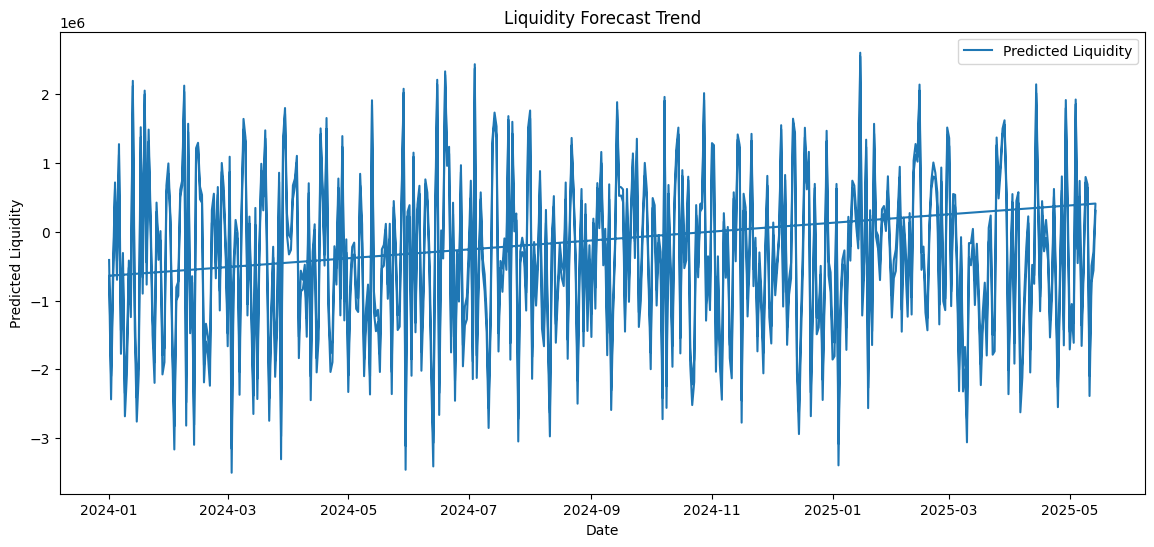

In [28]:
plt.figure(figsize=(14,6))

plt.plot(
    df_final['date'],
    df_final['predicted_liquidity'],
    label='Predicted Liquidity'
)

plt.title("Liquidity Forecast Trend")
plt.xlabel("Date")
plt.ylabel("Predicted Liquidity")

plt.legend()
plt.show()

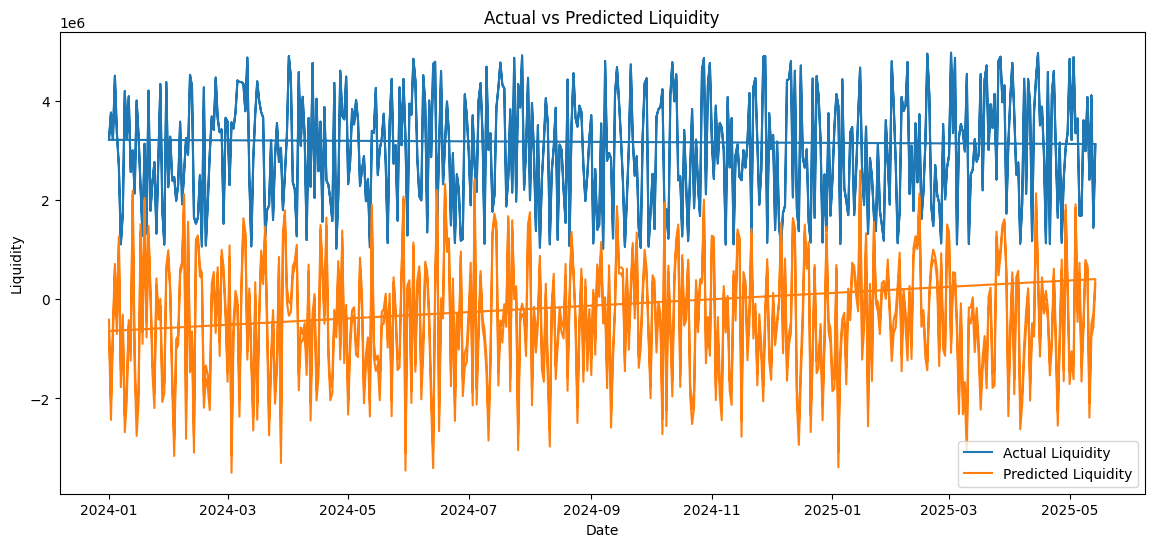

In [29]:
plt.figure(figsize=(14,6))

plt.plot(
    df_final['date'],
    df_final['actual_liquidity'],
    label='Actual Liquidity'
)

plt.plot(
    df_final['date'],
    df_final['predicted_liquidity'],
    label='Predicted Liquidity'
)

plt.title("Actual vs Predicted Liquidity")
plt.xlabel("Date")
plt.ylabel("Liquidity")

plt.legend()
plt.show()

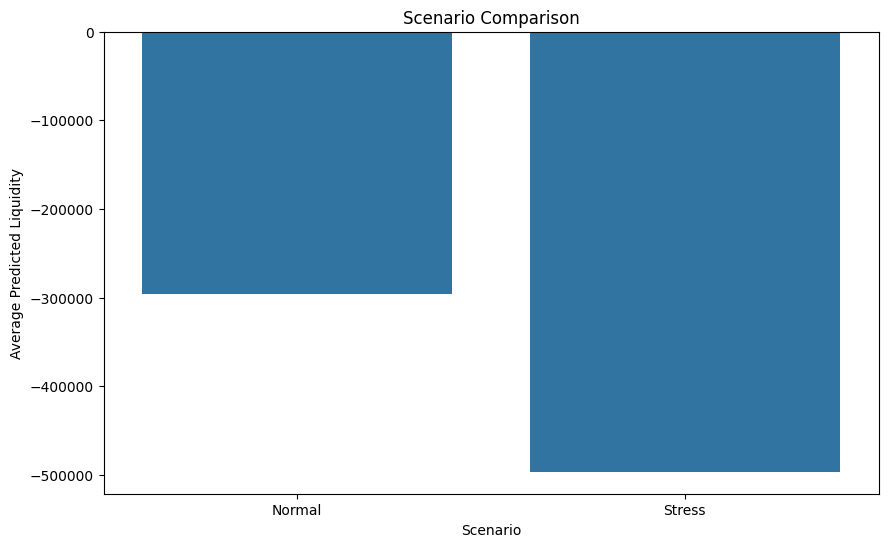

In [30]:
scenario_data = (
    df_final.groupby('scenario')['predicted_liquidity']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='scenario',
    y='predicted_liquidity',
    data=scenario_data
)

plt.title("Scenario Comparison")
plt.xlabel("Scenario")
plt.ylabel("Average Predicted Liquidity")

plt.show()

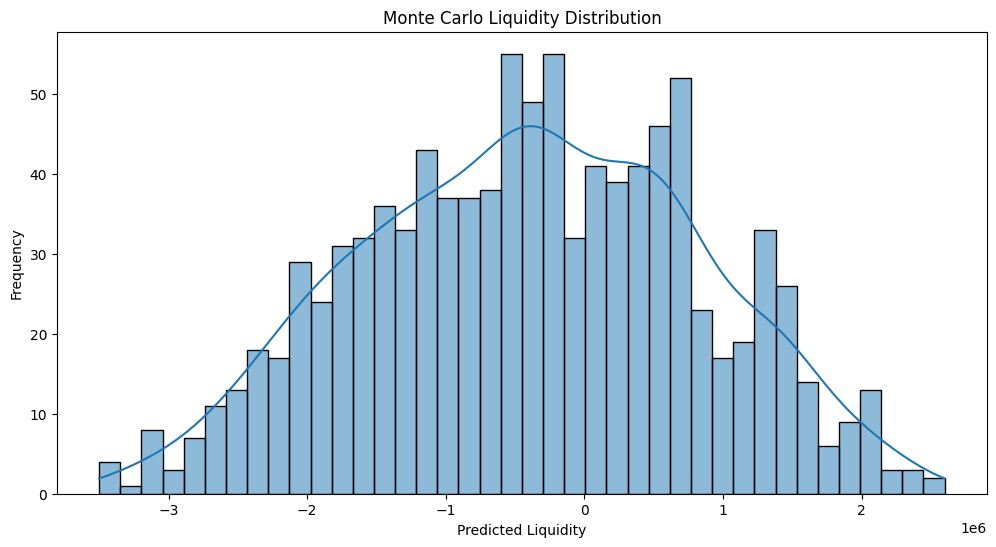

In [31]:
plt.figure(figsize=(12,6))

sns.histplot(
    df_final['predicted_liquidity'],
    bins=40,
    kde=True
)

plt.title("Monte Carlo Liquidity Distribution")
plt.xlabel("Predicted Liquidity")
plt.ylabel("Frequency")

plt.show()

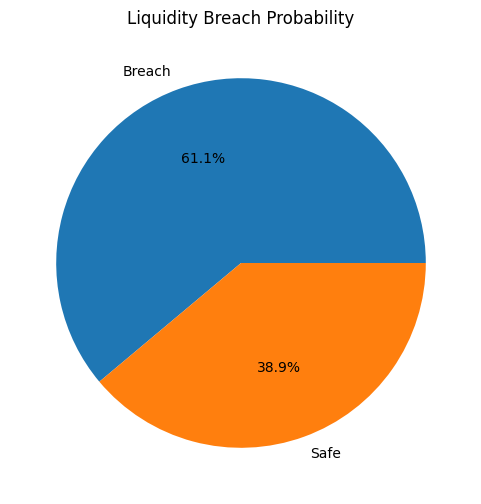

In [32]:
labels = ['Breach', 'Safe']
sizes = [
    Breach_Probability,
    100 - Breach_Probability
]

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title("Liquidity Breach Probability")

plt.show()

In [38]:
from sklearn.ensemble import RandomForestRegressor
features = [
    'loan_inflows',
    'borrowing_outflows',
    'repo_rate',
    'cp_rate',
    'liquidity_index',
    'alm_gap',
    'funding_risk_exposure',
    'variance'
]

X = df_final[features]
y = df_final['predicted_liquidity']
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X, y)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [39]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

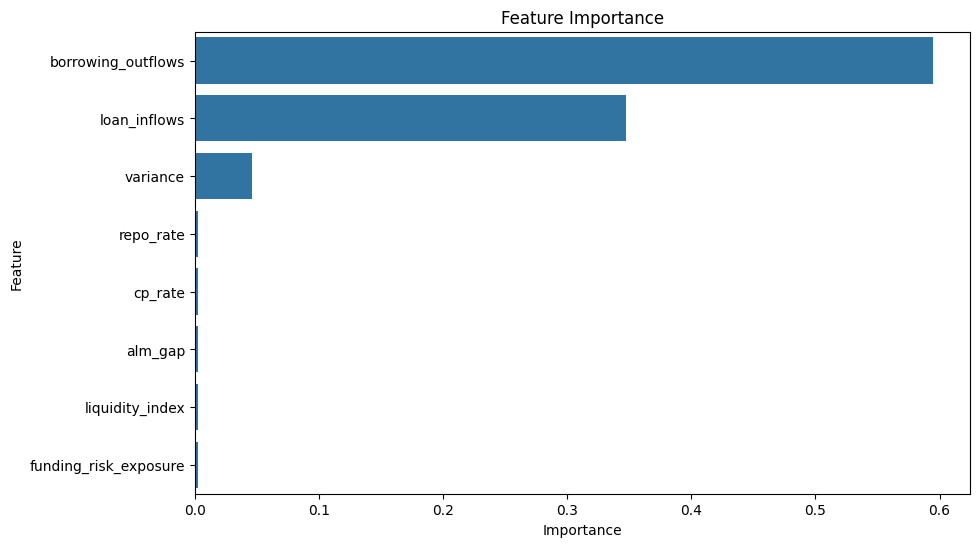

In [41]:

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()

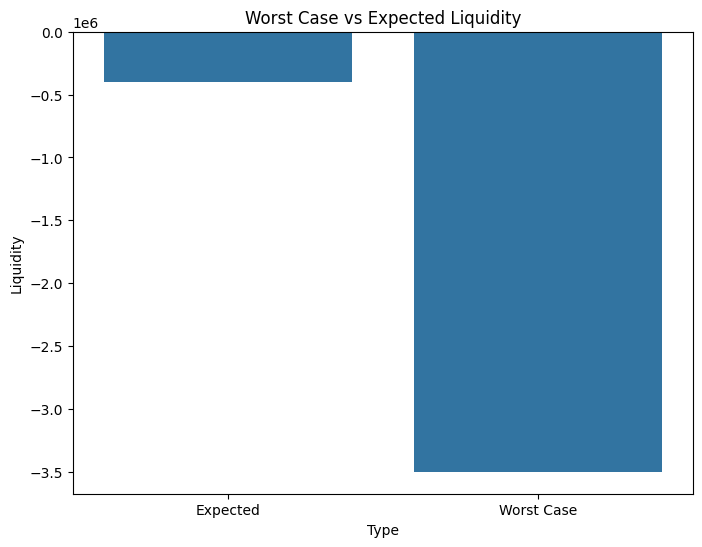

In [42]:
comparison = pd.DataFrame({
    'Type': ['Expected', 'Worst Case'],
    'Liquidity': [Expected_Liquidity, Worst_Case]
})

plt.figure(figsize=(8,6))

sns.barplot(
    x='Type',
    y='Liquidity',
    data=comparison
)

plt.title("Worst Case vs Expected Liquidity")

plt.show()